<a href="https://colab.research.google.com/github/nithisharul/Movie-Sentiment-Analysis-NLP-/blob/main/Oppenheimer_comments_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement : sentiment analysis of the comments of a movie trailer [Oppenheimer]

In [ ]:
!python -m textblob.download_corpora


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving OppenheimerComments.xlsx.xlsx to OppenheimerComments.xlsx.xlsx


In [ ]:
import pandas as pd


xls = pd.ExcelFile("OppenheimerComments.xlsx.xlsx")
print("Sheet names:", xls.sheet_names)


Sheet names: ['Input', 'OppenheimerComments']


In [ ]:
df = pd.read_excel("OppenheimerComments.xlsx.xlsx", sheet_name="OppenheimerComments")


df.head()


,Channel URL,Name,Comment,Time,Likes,Reply Count,Reply Author,Reply,Published,Updated
0,http://www.youtube.com/@msgreat3648,@msgreat3648,Prasing the man makeing a boom that destroy vi...,2025-04-06T16:21:09Z,1.0,0.0,NaN,NaN,NaN,NaN
1,http://www.youtube.com/@dansonpharmaceutical3608,@dansonpharmaceutical3608,Oppenheimer 2023 Topic Thunder 2008 Robert Dow...,2025-04-05T03:17:58Z,0.0,0.0,NaN,NaN,NaN,NaN
2,http://www.youtube.com/@IsraelNowIsraelForever,@IsraelNowIsraelForever,Sir Christopher&#39;s next Manhattan Project w...,2025-04-04T12:49:51Z,0.0,0.0,NaN,NaN,NaN,NaN
3,http://www.youtube.com/@matt-rw6li,@matt-rw6li,Japan surrendered when the Russians came down ...,2025-04-04T09:52:59Z,0.0,0.0,NaN,NaN,NaN,NaN
4,http://www.youtube.com/@Torenoqop,@Torenoqop,Wow,2025-04-01T00:11:00Z,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
!pip install vaderSentiment transformers nltk wordcloud

In [ ]:

!pip install textblob openpyxl


import pandas as pd
from textblob import TextBlob


xls = pd.ExcelFile("/content/OppenheimerComments.xlsx.xlsx")

print("Sheet names:", xls.sheet_names)


df = xls.parse("OppenheimerComments")


df = df.dropna(subset=['Comment'])
df['Comment'] = df['Comment'].astype(str)


def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0


df['Sentiment Score'] = df['Comment'].apply(get_sentiment)

def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment Score'].apply(classify_sentiment)
print("Sentiment Counts:")
print(df['Sentiment'].value_counts())

print("\nAverage Sentiment Score:", round(df['Sentiment Score'].mean(), 3))

df[['Comment', 'Sentiment Score', 'Sentiment']].head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
Sheet names: ['Input', 'OppenheimerComments']
Sentiment Counts:
Sentiment
Neutral     26
Positive    17
Negative     7
Name: count, dtype: int64

Average Sentiment Score: 0.052


,Comment,Sentiment Score,Sentiment
0,Prasing the man makeing a boom that destroy vi...,0.100000,Positive
1,Oppenheimer 2023 Topic Thunder 2008 Robert Dow...,-0.166667,Negative
2,Sir Christopher&#39;s next Manhattan Project w...,0.050000,Positive
3,Japan surrendered when the Russians came down ...,-0.155556,Negative
4,Wow,0.100000,Positive


In [ ]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:

!pip install textblob openpyxl


from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud


xls = pd.ExcelFile("OppenheimerComments.xlsx.xlsx")
df = pd.read_excel(xls, sheet_name="OppenheimerComments")


df = df.dropna(subset=["Comment"])


def get_sentiment(text):
    blob = TextBlob(str(text))
    return round(blob.sentiment.polarity, 6)


df["Sentiment Score"] = df["Comment"].apply(get_sentiment)


def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Sentiment Score"].apply(classify_sentiment)

positive_words = ""
negative_words = ""

def get_words_by_sentiment(text):
    pos_words = ""
    neg_words = ""
    blob = TextBlob(str(text))
    for word in blob.words:
        polarity = TextBlob(word).sentiment.polarity
        if polarity > 0:
            pos_words += word + " "
        elif polarity < 0:
            neg_words += word + " "
    return pos_words, neg_words


for comment in df['Comment']:
    pw, nw = get_words_by_sentiment(comment)
    positive_words += pw
    negative_words += nw


sentiment_counts = df["Sentiment"].value_counts()
avg_sentiment = round(df["Sentiment Score"].mean(), 6)

print("Sentiment Counts:\n", sentiment_counts)
print("\nAverage Sentiment Score:", avg_sentiment)


df[["Comment", "Sentiment Score", "Sentiment"]].head()


Sentiment Counts:
 Sentiment
Neutral     27
Positive    16
Negative     7
Name: count, dtype: int64

Average Sentiment Score: 0.052392


,Comment,Sentiment Score,Sentiment
0,Prasing the man makeing a boom that destroy vi...,0.100000,Positive
1,Oppenheimer 2023 Topic Thunder 2008 Robert Dow...,-0.166667,Negative
2,Sir Christopher&#39;s next Manhattan Project w...,0.050000,Positive
3,Japan surrendered when the Russians came down ...,-0.155556,Negative
4,Wow,0.100000,Positive


In [ ]:
positive_words


'filled epic Wow love love favorite more Welcome legendary experienced first very very socially good glad magnificent new Thanks clean clean action best wow peaky first great Many intelligent enjoying sure responsible '


=== Sentiment Analysis Results ===
Sentiment Distribution:
Sentiment
Neutral     35
Positive    10
Negative     5
Name: count, dtype: int64

Average Sentiment Score: 0.052392

Positive Words WordCloud


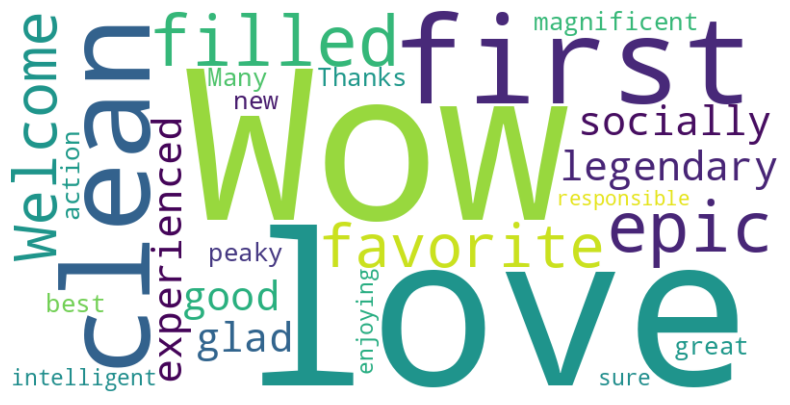


Negative Words WordCloud


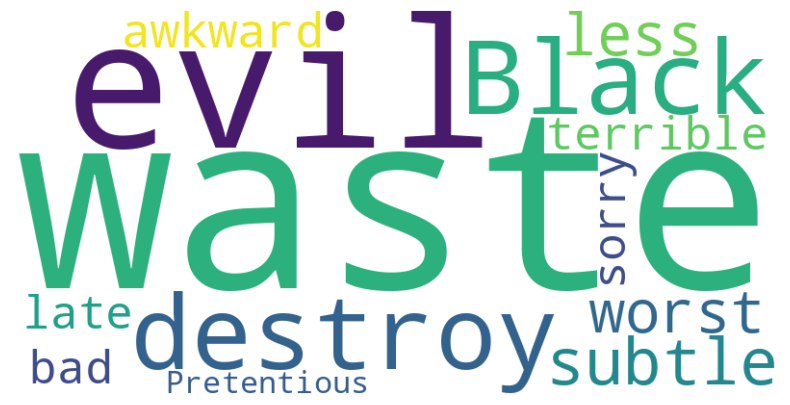

In [ ]:
# Install necessary packages
!pip install textblob openpyxl wordcloud

# Download ALL required NLTK data (including punkt_tab)
import nltk
nltk.download('all', quiet=True)  # This will download all NLTK data including punkt_tab

# Alternative: Download only what's needed (if you want to be more selective)
# nltk.download('punkt')
# nltk.download('punkt_tab')  # This is the specific missing resource
# nltk.download('brown')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')

# Import libraries
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load Excel file - make sure the filename is correct (you had .xlsx.xlsx)
try:
    df = pd.read_excel("OppenheimerComments.xlsx.xlsx", sheet_name="OppenheimerComments")
except FileNotFoundError:
    print("Error: File not found. Please check the filename and path.")
    print("Make sure it's exactly 'OppenheimerComments.xlsx' without double extensions")
    raise

# Drop rows with missing comments
df = df.dropna(subset=["Comment"])

# Function to calculate sentiment score with error handling
def get_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return round(blob.sentiment.polarity, 6)
    except Exception as e:
        print(f"Error processing text: {str(e)}")
        return 0.0  # Return neutral for errors

# Apply sentiment analysis
df["Sentiment Score"] = df["Comment"].apply(get_sentiment)

# Classify sentiment
def classify_sentiment(score):
    if score > 0.1:  # Slightly higher threshold for positive
        return "Positive"
    elif score < -0.1:  # Slightly lower threshold for negative
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Sentiment Score"].apply(classify_sentiment)

# Extract words for word cloud - more efficient implementation
positive_words = " ".join(
    word for comment in df['Comment']
    for word in TextBlob(str(comment)).words
    if TextBlob(word).sentiment.polarity > 0
)

negative_words = " ".join(
    word for comment in df['Comment']
    for word in TextBlob(str(comment)).words
    if TextBlob(word).sentiment.polarity < 0
)

# Print summary
sentiment_counts = df["Sentiment"].value_counts()
avg_sentiment = round(df["Sentiment Score"].mean(), 6)

print("\n=== Sentiment Analysis Results ===")
print("Sentiment Distribution:")
print(sentiment_counts)
print(f"\nAverage Sentiment Score: {avg_sentiment}")

# Generate word clouds if we have words
if positive_words:
    print("\nPositive Words WordCloud")
    wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_words)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("\nNo positive words found for word cloud")

if negative_words:
    print("\nNegative Words WordCloud")
    wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_words)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("\nNo negative words found for word cloud")